In [ ]:
# Some package imports
from pathlib import Path
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and set up results

In [ ]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent
RUNNING_DIR = PROJECT_ROOT / "running"
SRC_DIR = PROJECT_ROOT / "src"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

for path in [str(PROJECT_ROOT), str(RUNNING_DIR), str(SRC_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

def load_result_pickle(path: str | Path):
    path = Path(path)
    with path.open("rb") as f:
        return pickle.load(f)

def load_all_result_pickles(results_dir: str | Path):
    results_dir = Path(results_dir)
    pickle_paths = sorted(results_dir.rglob("simulation_result_run_*.pkl"))
    if not pickle_paths:
        raise FileNotFoundError(f"No result pickle files were found under: {results_dir}")
    return [load_result_pickle(path) for path in pickle_paths], pickle_paths

def get_most_recent_batch_dir(outputs_dir: str | Path) -> Path:
    """
    Return the most recently modified batch folder inside BigProject/outputs. Assumes each simulation batch is stored in its own subfolder (timestamp folder).
    """
    outputs_dir = Path(outputs_dir)

    if not outputs_dir.exists():
        raise FileNotFoundError(f"Outputs directory does not exist: {outputs_dir}")

    subdirs = [p for p in outputs_dir.iterdir() if p.is_dir() and p.name != "for_r"]

    if not subdirs:
        raise FileNotFoundError(f"No batch subfolders were found inside: {outputs_dir}")

    return max(subdirs, key=lambda p: p.stat().st_mtime)

# Option 1: manually specify a batch folder
# results_dir = OUTPUTS_DIR / "2026-05-26_19-10-32" 

# Option 2: automatically use the most recent batch folder
results_dir = get_most_recent_batch_dir(OUTPUTS_DIR)
print("Using results folder:", results_dir)

results_list, pickle_paths = load_all_result_pickles(results_dir)
print("Loaded result files:", len(results_list))

Using results folder: \\lightning.bu.binghamton.edu\WISE\sescott1\Masters\523\Emotion-Contagion\BigProject\outputs\2026-05-26_18-15-06
Loaded result files: 180


### What the objects look like (give this to the LLM of your choice when asking for analysis help, so they know how results are structured)
@dataclass
class SimulationResults:
    run_id: Any                                  # scalar
    seed: int                                    # scalar

    state: SimulationState                       # final state object
      state.agents: List[Dict[str, Any]]         # [agent]
      state.leader_index: int                    # scalar
      state.intimacy_matrix: np.ndarray          # [agent, agent]
      state.assignments: np.ndarray | None       # [agent]
      state.time: int                            # scalar
      state.metadata: Dict[str, Any]             # config / run metadata

    initial_conditions: pd.DataFrame             # [agent, variable]
    emotion_history: List[List[float]]           # [t_state][agent]; t_state = 0 is the initial state before timestep 0, len(emotion_history) = max_iterations + 1
    avg_emotion_history: List[float]             # [t], member-only avg emotion per timestep, len(avg_emotion_history) = max_iterations
    buddies_per_timestep: List[List[Tuple[int, int]]]   # [t][interaction_pair]; each pair is (i, j) in full-agent indexing, member-member only
    interactions_per_timestep: List[int]         # [t]; number of member-member interactions at each timestep
    intervention_timesteps: List[int]            # [t_intervention]; sparse list of timesteps where leader intervened
    absorption_history: List[Dict[Tuple[int, int], float]]   # [t][(i, j)] cumulative absorption; cumulative absorption/change dictionary after each timestep
    final_absorption_dict: Dict[Tuple[int, int], float]      # [(i, j)] final cumulative absorption
    metadata: Dict[str, Any]                     # run-level metadata / parameters (like: network specifications, leader_style, condition_name, population_size, max_iterations, adaptive_intimacy)
    leader_summary: Dict[str, Any]               # small final leader summary (style, leader_index, leader_emotion, emotionManagementAbility, interventionThreshold, dampening)

batch = {
    "results": List[SimulationResults],          # [run]
    "summary_df": pd.DataFrame | None,           # [run, summary_variable]
    "output_dir": Path,                          # scalar
    "summary_path": Path | None,                 # scalar
    "conditions_used": List[Dict[str, Any]]     # [condition]
}

In [ ]:
# Build tables
def get_condition_key(results):
    return (results.metadata.get("structure"), results.metadata.get("leader_style"))

def build_avg_emotion_df(results_list):
    rows = []
    for results in results_list:
        structure = results.metadata.get("structure")
        leader_style = results.metadata.get("leader_style")
        condition_name = results.metadata.get("condition_name")

        for t, avg_emotion in enumerate(results.avg_emotion_history):
            rows.append(
                {
                    "run_id": results.run_id,
                    "seed": results.seed,
                    "condition_name": condition_name,
                    "structure": structure,
                    "leader_style": leader_style,
                    "time": t,
                    "avg_member_emotion": avg_emotion,
                }
            )
    return pd.DataFrame(rows)

def build_intervention_frequency_df(results_list):
    rows = []
    for results in results_list:
        structure = results.metadata.get("structure")
        leader_style = results.metadata.get("leader_style")
        condition_name = results.metadata.get("condition_name")
        intervention_set = set(results.intervention_timesteps)
        n_t = len(results.avg_emotion_history)

        for t in range(n_t):
            rows.append(
                {
                    "run_id": results.run_id,
                    "seed": results.seed,
                    "condition_name": condition_name,
                    "structure": structure,
                    "leader_style": leader_style,
                    "time": t,
                    "intervened": 1 if t in intervention_set else 0,
                }
            )
    return pd.DataFrame(rows)

def build_intervention_summary_df(results_list):
    rows = []
    for results in results_list:
        intervention_times = list(results.intervention_timesteps)
        rows.append(
            {
                "run_id": results.run_id,
                "seed": results.seed,
                "condition_name": results.metadata.get("condition_name"),
                "structure": results.metadata.get("structure"),
                "leader_style": results.metadata.get("leader_style"),
                "num_interventions": len(intervention_times),
                "first_intervention_time": intervention_times[0] if intervention_times else np.nan,
                "had_any_intervention": int(len(intervention_times) > 0),
            }
        )
    return pd.DataFrame(rows)

def build_intervention_raster_df(results_list):
    rows = []
    for results in results_list:
        for t in results.intervention_timesteps:
            rows.append(
                {
                    "run_id": results.run_id,
                    "seed": results.seed,
                    "condition_name": results.metadata.get("condition_name"),
                    "structure": results.metadata.get("structure"),
                    "leader_style": results.metadata.get("leader_style"),
                    "time": t,
                }
            )
    return pd.DataFrame(rows)

avg_df = build_avg_emotion_df(results_list)
intervention_freq_df = build_intervention_frequency_df(results_list)
intervention_summary_df = build_intervention_summary_df(results_list)
intervention_raster_df = build_intervention_raster_df(results_list)

avg_df.shape, intervention_summary_df.shape, intervention_freq_df.shape, intervention_raster_df.shape

((42300, 7), (180, 8), (42300, 7), (11119, 6))

In [6]:
# Helper functions for plotting
structure_order = ["random", "community", "core_periphery"]
leader_style_order = ["No_Intervention", "High_Initially_Constrained", "Low_Initially_Constrained"]

def get_ax(axes, structure, leader_style):
    row = structure_order.index(structure)
    col = leader_style_order.index(leader_style)
    return axes[row, col]

def format_condition_title(structure, leader_style):
    return f"{structure}\n{leader_style}"

# Some plotting

### Avg team emotion over time w/ s.d. 1, 2, 3
Shows variability across repititions (the s.d. shading/bands), per condition
- narrower = more similarity across repetitions
- wider = more difference across repetitions
- line goes upward over time → teams tend to improve emotionally
- line stays low/negative → teams remain emotionally worse off
- line rises fast at the beginning → the condition stabilizes/improves the team quickly
- line is noisy or flat with wide band → outcomes are unstable or inconsistent

can be used to compare things like:
- final level of the line
- speed of recovery/improvement
- amount of variability

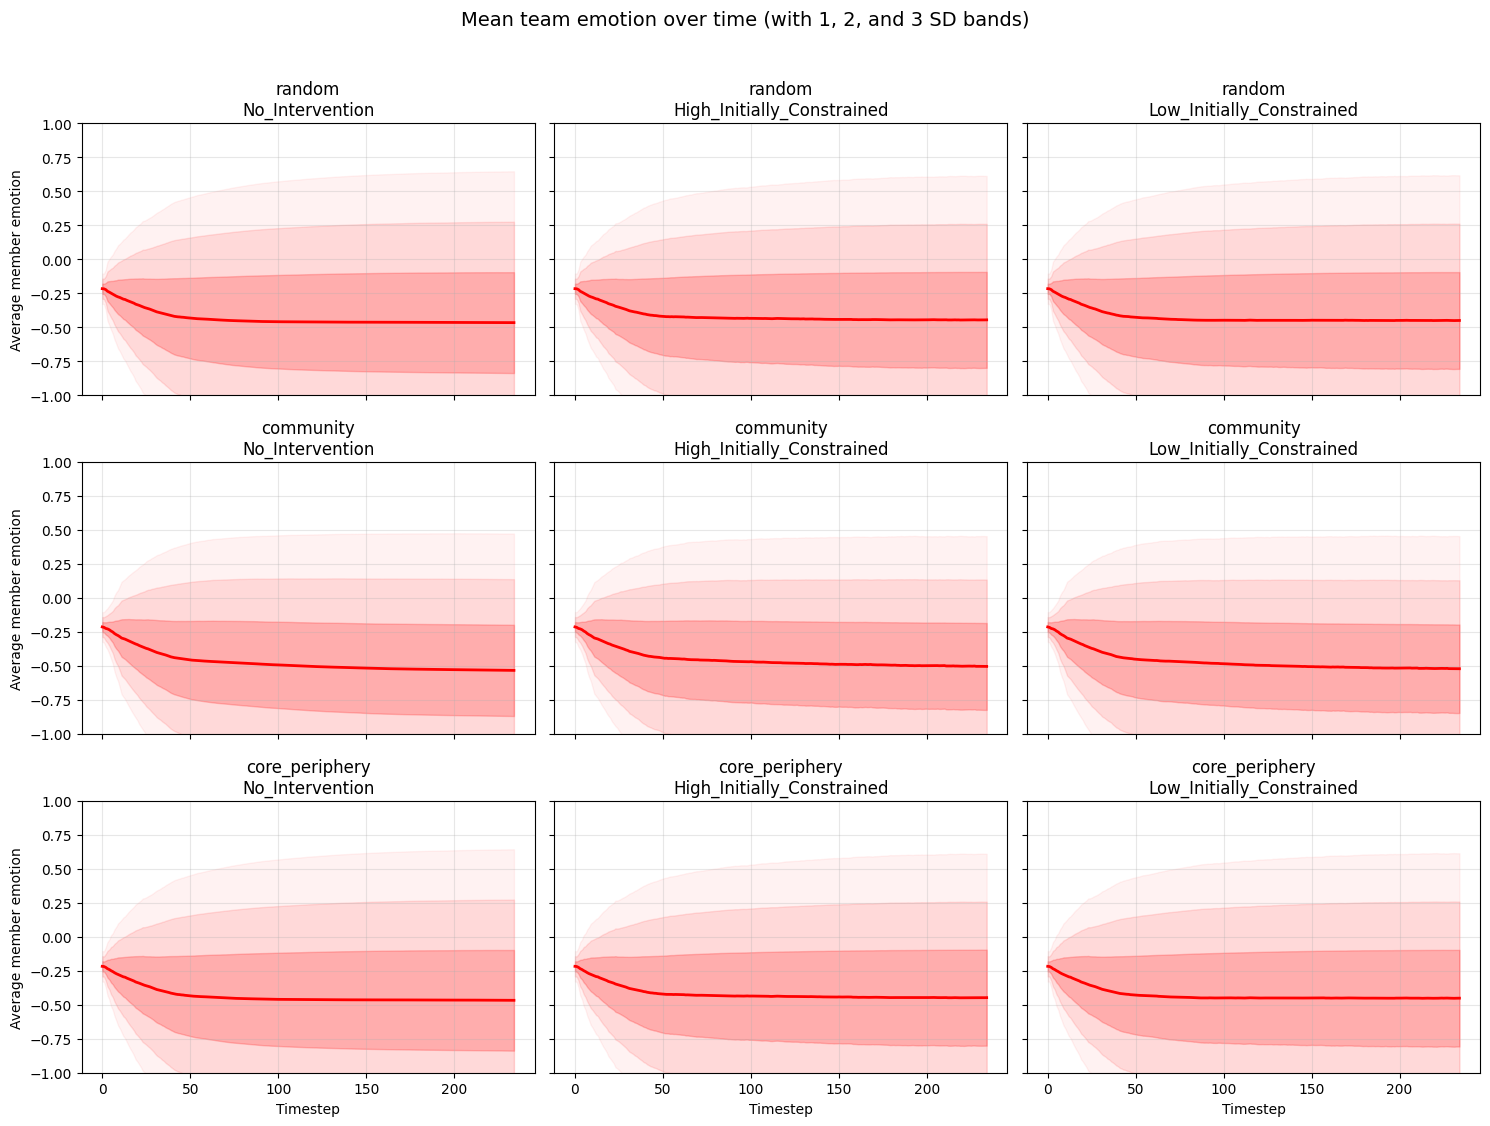

In [14]:
emotion_summary_df = (avg_df.groupby(["structure", "leader_style", "time"], as_index=False).agg(
                                                                                                mean_avg_member_emotion=("avg_member_emotion", "mean"), 
                                                                                                sd_avg_member_emotion=("avg_member_emotion", "std"), 
                                                                                                n_runs=("avg_member_emotion", "count")
                                                                                                )
                                                                                                )
emotion_summary_df["sd_avg_member_emotion"] = emotion_summary_df["sd_avg_member_emotion"].fillna(0.0)

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True, sharey=True)
for structure in structure_order:
    for leader_style in leader_style_order:
        ax = get_ax(axes, structure, leader_style)
        sub = emotion_summary_df[(emotion_summary_df["structure"] == structure) & (emotion_summary_df["leader_style"] == leader_style)].sort_values("time")
        if not sub.empty:
            x = sub["time"].to_numpy()
            y = sub["mean_avg_member_emotion"].to_numpy()
            s = sub["sd_avg_member_emotion"].to_numpy()

            ax.plot(x, y, color="red", linewidth=2)

            ax.fill_between(x, y - 3*s, y + 3*s, color="red", alpha=0.05)
            ax.fill_between(x, y - 2*s, y + 2*s, color="red", alpha=0.10)
            ax.fill_between(x, y - 1*s, y + 1*s, color="red", alpha=0.20)

        ax.set_title(format_condition_title(structure, leader_style))
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)

for ax in axes[-1, :]: ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Average member emotion")

fig.suptitle("Mean team emotion over time (with 1, 2, and 3 SD bands)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

### Fraction of runs in which an intervention occurred

Can be used from the perspective of: How likely is an intervention at each timestep under a certain condition?

How to interpret values:
- value near 1 → leader intervenes at that timestep in almost all runs
- value near 0 → leader almost never intervenes there
- peak early in the simulation → intervention tends to happen early
- broad spread over many timesteps → intervention timing is variable
- sharp peak at one timestep → intervention timing is very consistent

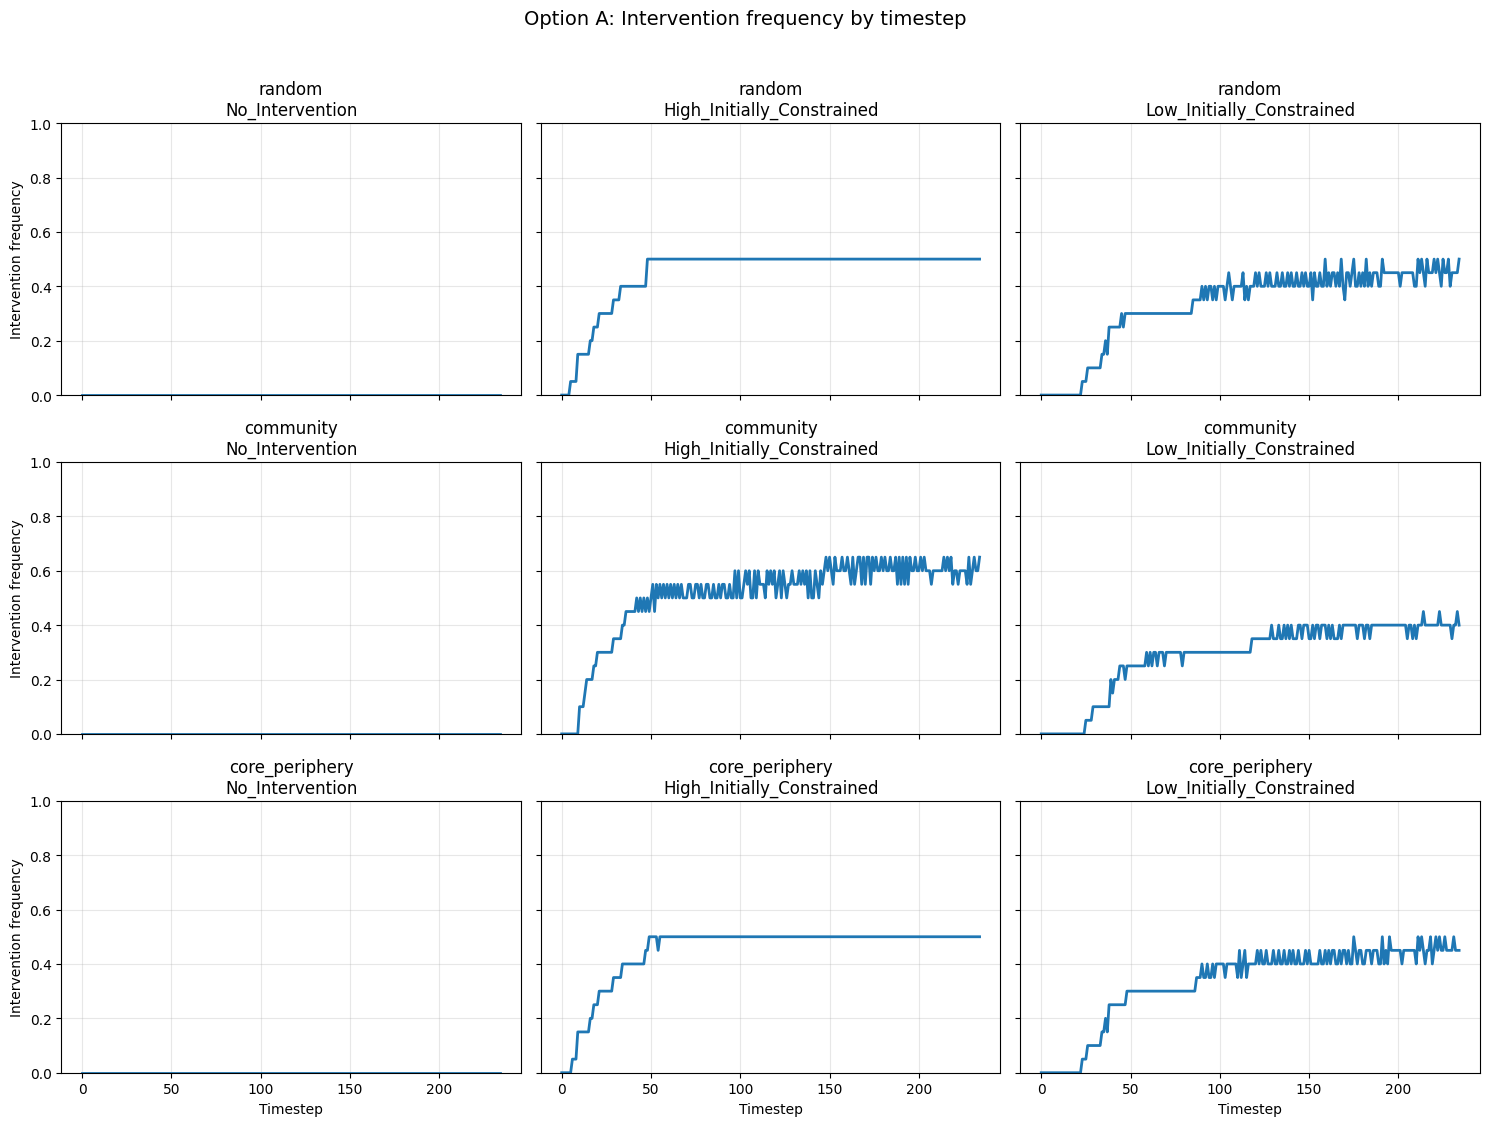

In [ ]:
freq_plot_df = (intervention_freq_df.groupby(["structure", "leader_style", "time"], as_index=False)["intervened"].mean().rename(columns={"intervened": "intervention_frequency"}))

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True, sharey=True)
for structure in structure_order:
    for leader_style in leader_style_order:
        ax = get_ax(axes, structure, leader_style)
        sub = freq_plot_df[(freq_plot_df["structure"] == structure) & (freq_plot_df["leader_style"] == leader_style)]

        if not sub.empty: ax.plot(sub["time"], sub["intervention_frequency"], linewidth=2)
        ax.set_title(format_condition_title(structure, leader_style))
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

for ax in axes[-1, :]: ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Intervention frequency")

fig.suptitle("Option A: Intervention frequency by timestep", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

In [9]:
intervention_summary_table = (intervention_summary_df.groupby(["structure", "leader_style"], as_index=False).agg(
                                                                                                                mean_num_interventions=("num_interventions", "mean"),
                                                                                                                sd_num_interventions=("num_interventions", "std"),
                                                                                                                mean_first_intervention_time=("first_intervention_time", "mean"),
                                                                                                                prop_any_intervention=("had_any_intervention", "mean"),
                                                                                                                n_runs=("run_id", "count")
                                                                                                                )
                                                                                                                )
intervention_summary_table
#intervention_summary_table.sort_values(["structure", "leader_style"])

,structure,leader_style,mean_num_interventions,sd_num_interventions,mean_first_intervention_time,prop_any_intervention,n_runs
0,community,High_Initially_Constrained,119.25,99.616039,40.076923,0.65,20
1,community,Low_Initially_Constrained,68.30,90.128038,77.333333,0.45,20
2,community,No_Intervention,0.00,0.000000,NaN,0.00,20
3,core_periphery,High_Initially_Constrained,105.55,108.828438,23.800000,0.50,20
4,core_periphery,Low_Initially_Constrained,78.40,92.370763,64.500000,0.50,20
5,core_periphery,No_Intervention,0.00,0.000000,NaN,0.00,20
6,random,High_Initially_Constrained,105.70,108.972763,23.600000,0.50,20
7,random,Low_Initially_Constrained,78.75,92.175391,62.900000,0.50,20
8,random,No_Intervention,0.00,0.000000,NaN,0.00,20


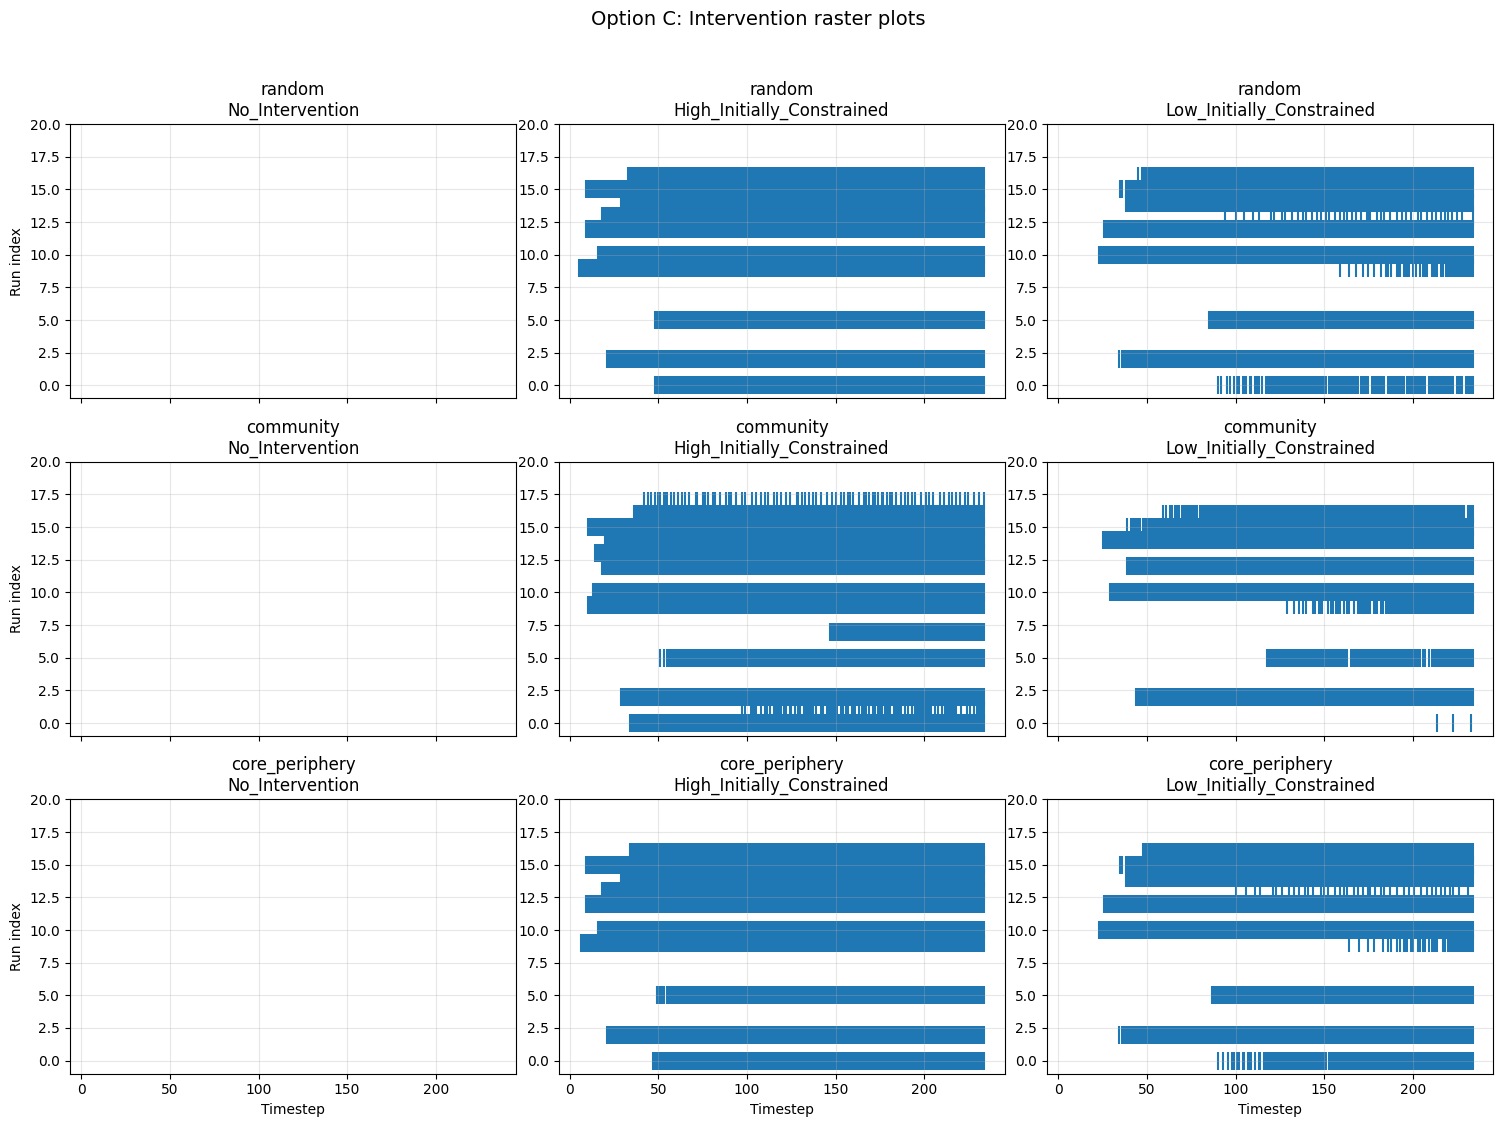

In [11]:
# Raster plot of interventions for each run, grouped by condition; one row per run and marks intervention times
run_order_df = (intervention_summary_df[["run_id", "structure", "leader_style"]].drop_duplicates().sort_values(["structure", "leader_style", "run_id"]))

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True, sharey=False)
for structure in structure_order:
    for leader_style in leader_style_order:
        ax = get_ax(axes, structure, leader_style)

        runs_sub = run_order_df[(run_order_df["structure"] == structure) & (run_order_df["leader_style"] == leader_style)].reset_index(drop=True)
        raster_sub = intervention_raster_df[(intervention_raster_df["structure"] == structure) & (intervention_raster_df["leader_style"] == leader_style)]
        run_to_y = {run_id: i for i, run_id in enumerate(runs_sub["run_id"])}

        if not raster_sub.empty:
            x = raster_sub["time"].to_numpy()
            y = raster_sub["run_id"].map(run_to_y).to_numpy()
            ax.scatter(x, y, marker="|", s=150)

        ax.set_title(format_condition_title(structure, leader_style))
        ax.grid(True, alpha=0.3)

        if len(runs_sub) > 0: ax.set_ylim(-1, len(runs_sub))

for ax in axes[-1, :]: ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Run index")

fig.suptitle("Option C: Intervention raster plots", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

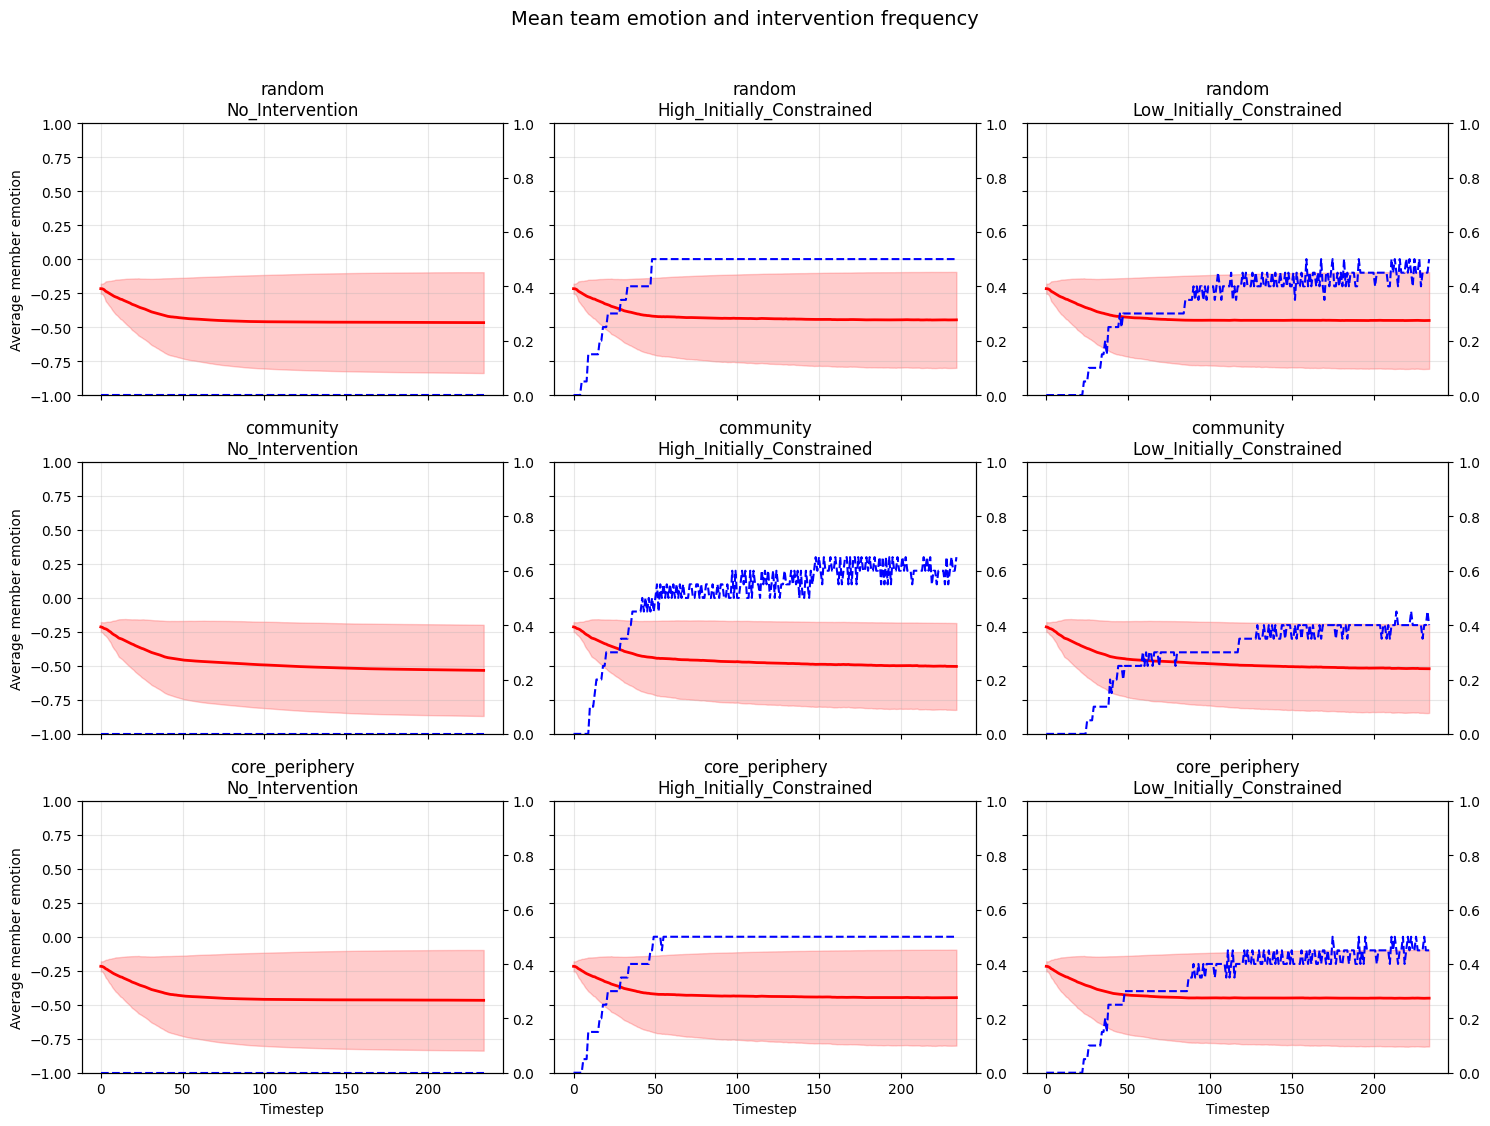

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True, sharey=True)

for structure in structure_order:
    for leader_style in leader_style_order:
        ax = get_ax(axes, structure, leader_style)

        emo = emotion_summary_df[(emotion_summary_df["structure"] == structure) & (emotion_summary_df["leader_style"] == leader_style)].sort_values("time")
        freq = freq_plot_df[(freq_plot_df["structure"] == structure) & (freq_plot_df["leader_style"] == leader_style)].sort_values("time")
        if not emo.empty:
            x = emo["time"].to_numpy()
            y = emo["mean_avg_member_emotion"].to_numpy()
            s = emo["sd_avg_member_emotion"].to_numpy()
            ax.plot(x, y, color="red", linewidth=2)
            ax.fill_between(x, y - s, y + s, color="red", alpha=0.2)

        ax2 = ax.twinx()
        if not freq.empty: ax2.plot(freq["time"], freq["intervention_frequency"], color="blue", linestyle="--", linewidth=1.5)
        ax2.set_ylim(0, 1)

        ax.set_title(format_condition_title(structure, leader_style))
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)

for ax in axes[-1, :]:  ax.set_xlabel("Timestep")
for ax in axes[:, 0]: ax.set_ylabel("Average member emotion")

fig.suptitle("Mean team emotion and intervention frequency", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()